# EDA

## Loading

In [20]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "creditcard.csv"
)

df = pd.read_csv(DATA_PATH)

df.shape

(284807, 31)

## Inspection

In [21]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [23]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Imbalance

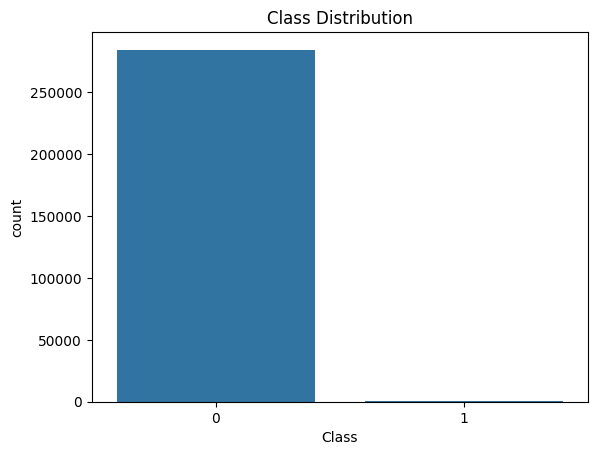

In [24]:
sns.countplot(
    data=df,
    x="Class",
)

plt.title("Class Distribution")
plt.show()

## Duplicate Analysis

In [5]:
duplicated_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicated_rows}")

Duplicate rows: 1081


In [6]:
duplicate_mask = df.duplicated(keep=False)

df_duplicates = df[duplicate_mask]

print("Total rows involved in duplicates:", len(df_duplicates))

print("\nClass distribution among duplicated rows:")
print(df_duplicates["Class"].value_counts())

print("\nClass distribution among duplicated rows (%):")
print(
    df_duplicates["Class"]
    .value_counts(normalize=True)
    .mul(100)
)

Total rows involved in duplicates: 1854

Class distribution among duplicated rows:
Class
0    1822
1      32
Name: count, dtype: int64

Class distribution among duplicated rows (%):
Class
0    98.274002
1     1.725998
Name: proportion, dtype: float64


In [7]:
duplicate_counts = (
    df.value_counts()
    .reset_index(name="count")
)

duplicate_counts = duplicate_counts[
    duplicate_counts["count"] > 1
]

duplicate_counts["Class"].value_counts()

Class
0    760
1     13
Name: count, dtype: int64

In [8]:
duplicate_counts["count"].value_counts().sort_index()

count
2     611
3      66
4      81
5      10
6       1
9       2
18      2
Name: count, dtype: int64

In [9]:
fraud_duplicates = df_duplicates[
    df_duplicates["Class"] == 1
]

print(f"Duplicated fraud rows: {len(fraud_duplicates)}")

Duplicated fraud rows: 32


In [10]:
fraud_duplicate_counts = (
    fraud_duplicates
    .value_counts()
    .sort_values(ascending=False)
)

fraud_duplicate_counts.head(20)

Time      V1          V2         V3          V4         V5          V6         V7          V8          V9         V10         V11       V12         V13        V14         V15        V16         V17         V18        V19        V20        V21         V22        V23        V24        V25        V26        V27        V28        Amount  Class
68207.0   -13.192671  12.785971  -9.906650   3.320337   -4.801176    5.760059  -18.750889  -37.353443  -0.391540  -5.052502   4.406806  -4.610756   -1.909488  -9.072711   -0.226074  -6.211557   -6.248145   -3.149247   0.051576  -3.493050   27.202839  -8.887017   5.303607  -0.639435   0.263203  -0.108877   1.269566   0.939407  1.00    1        6
94362.0   -26.457745  16.497472  -30.177317  8.904157   -17.892600  -1.227904  -31.197329  -11.438920  -9.462573  -22.187089  4.419997  -10.592305  -0.703796  -3.926207   -2.400246  -6.809890   -12.462315  -5.501051  -0.567940   2.812241  -8.755698    3.460893   0.896538   0.254836  -0.738097  -0.966564  -7.26

In [11]:
duplicate_groups = (
    df[df.duplicated(keep=False)]
    .groupby(
        list(df.columns),
        dropna=False
    )
    .size()
    .reset_index(name="count")
)

duplicate_groups = duplicate_groups[
    duplicate_groups["count"] > 1
]

print(f"Duplicate groups: {len(duplicate_groups)}")

duplicate_groups[
    ["Time", "Amount", "Class", "count"]
].sort_values(
    "count",
    ascending=False
).head(20)

Duplicate groups: 773


,Time,Amount,Class,count
724,163152.0,7.56,0,18
723,163152.0,1.51,0,18
766,170731.0,0.76,0,9
146,43153.0,0.76,0,9
281,68207.0,1.00,1,6
286,68780.0,320.05,0,5
287,68780.0,282.98,0,5
288,68780.0,281.47,0,5
285,68780.0,336.70,0,5
250,64947.0,5.96,0,5


In [12]:
feature_columns = [
    col for col in df.columns
    if col != "Class"
]

conflicting_duplicates = (
    df.groupby(feature_columns)["Class"]
    .nunique()
)

conflicting_duplicates = (
    conflicting_duplicates[
        conflicting_duplicates > 1
    ]
)

print(
    "Feature combinations with conflicting targets:",
    len(conflicting_duplicates)
)

Feature combinations with conflicting targets: 0


In [13]:
df_no_duplicates = df.drop_duplicates()

print("Original shape:", df.shape)
print("Without duplicates:", df_no_duplicates.shape)

print(
    "Rows removed:",
    len(df) - len(df_no_duplicates)
)

Original shape: (284807, 31)
Without duplicates: (283726, 31)
Rows removed: 1081


In [14]:
print("Original class distribution:")
print(df["Class"].value_counts())

print("\nAfter removing duplicates:")
print(df_no_duplicates["Class"].value_counts())

Original class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

After removing duplicates:
Class
0    283253
1       473
Name: count, dtype: int64


## Duplicate Analysis: Conclusion

The dataset contains 1,081 duplicated rows, corresponding to 773 distinct groups of duplicated records.

Exact duplicates were removed before the train/test split to prevent identical observations from being distributed across training and test sets.

The original dataset contained 284,807 rows, including 492 fraudulent transactions.

After removing exact duplicates, the dataset contains 283,726 rows, including 473 fraudulent transactions.

No conflicting target labels were identified among records with identical feature values.

In [17]:
df_clean = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)

Original shape: (284807, 31)
Clean shape: (283726, 31)


In [18]:
print("Original class distribution:")
print(df["Class"].value_counts())

print("\nClean class distribution:")
print(df_clean["Class"].value_counts())

Original class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Clean class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


## Amount

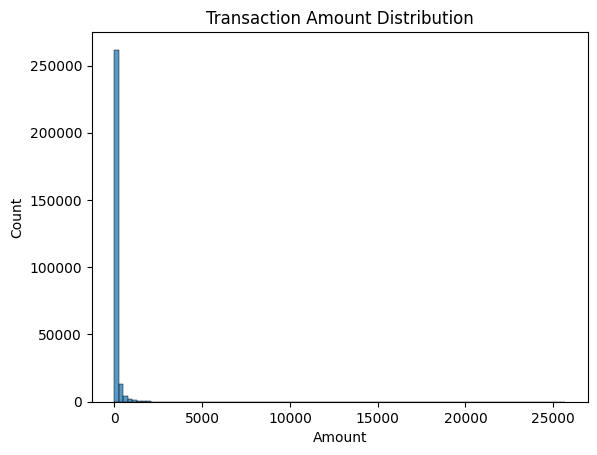

In [25]:
sns.histplot(
    data=df_clean,
    x="Amount",
    bins=100,
)

plt.title("Transaction Amount Distribution")
plt.show()

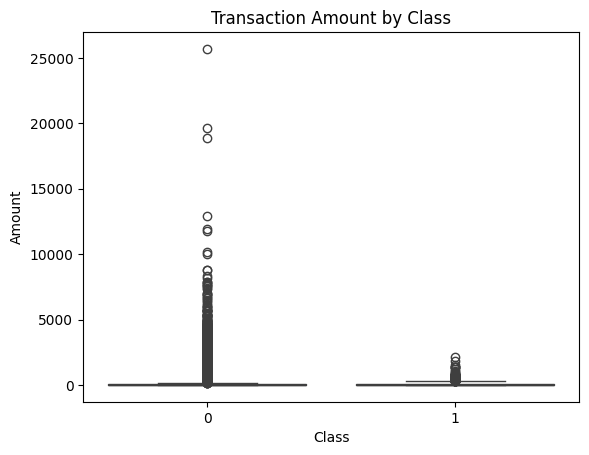

In [26]:
sns.boxplot(
    data=df_clean,
    x="Class",
    y="Amount",
)

plt.title("Transaction Amount by Class")
plt.show()

## Time

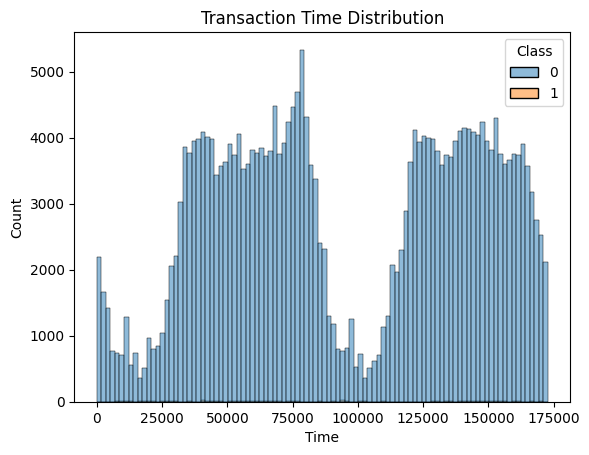

In [27]:
sns.histplot(
    data=df_clean,
    x="Time",
    hue="Class",
    bins=100,
)

plt.title("Transaction Time Distribution")
plt.show()

## Correlation

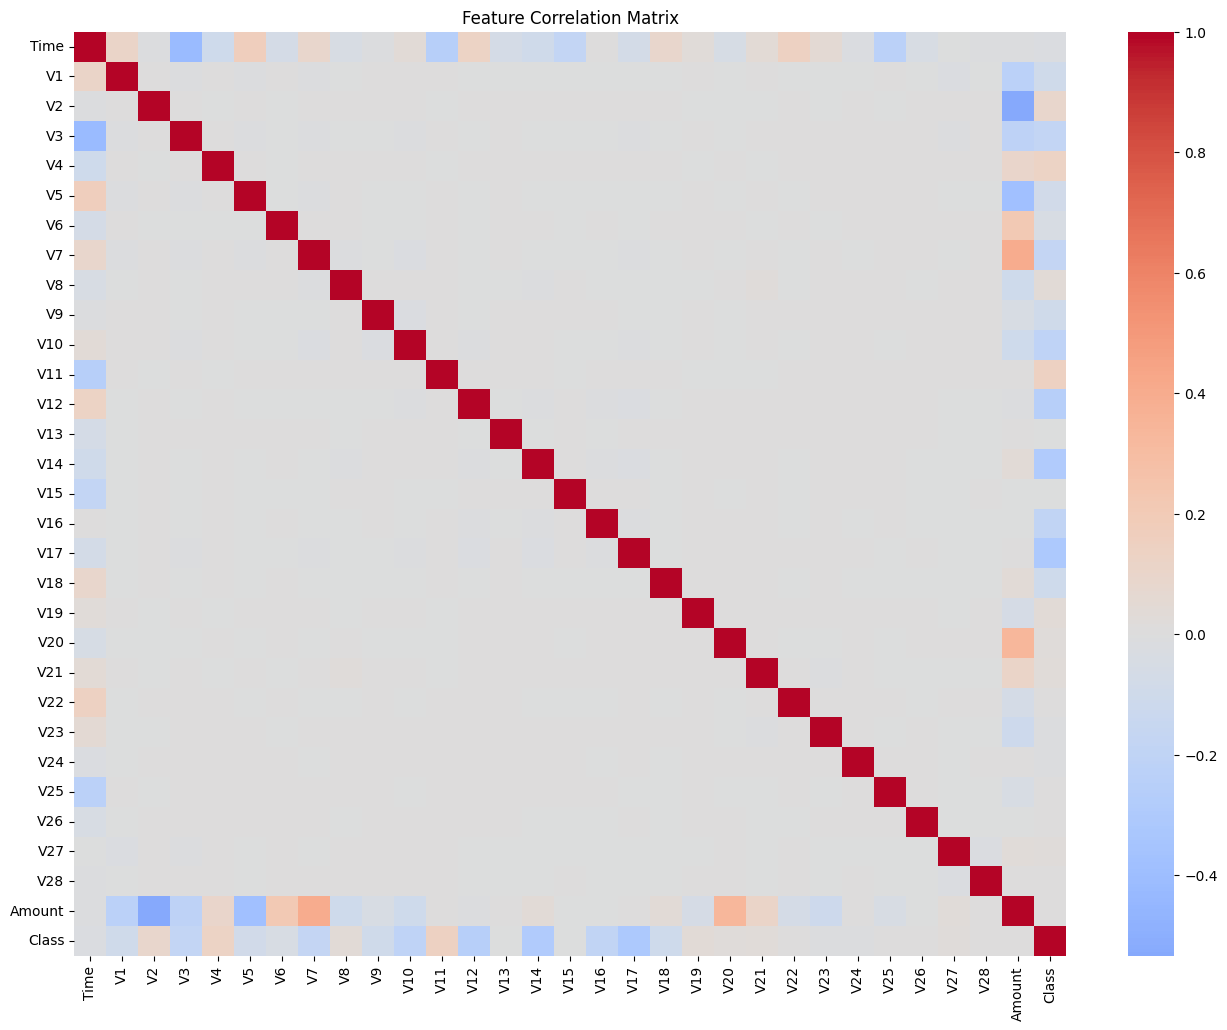

In [28]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df_clean.corr(),
    cmap="coolwarm",
    center=0,
)

plt.title("Feature Correlation Matrix")
plt.show()